<a href="https://colab.research.google.com/github/ariitooo/Building-a-Brain-Tumor-Detection-Using-Deep-Learning-MRI-Images-Detection-Using-Computer-Vision/blob/main/Building-a-Brain-Tumor-Detection-Using-Deep-Learning-MRI-Images-Detection-Using-Computer-Vision%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
import numpy as np
import random
from PIL import Image , ImageEnhance
import matplotlib.pyplot as plt


#keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense,Flatten,Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle


In [10]:
# !unzip "/content/drive/MyDrive/Colab Notebooks/archive.zip"
train_dir = "/content/Training"
test_dir ="/content/Testing"
# train_dir = "/content/drive/MyDrive/MRI images/Training"
# test_dir ="/content/drive/MyDrive/MRI images/Testing"

train_paths = []
train_labels =[]
for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir,label)):
    train_paths.append(os.path.join(train_dir,label,image))
    train_labels.append(label)

train_paths,train_labels = shuffle(train_paths,train_labels)


test_paths = []
test_labels =[]
for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir,label)):
    test_paths.append(os.path.join(test_dir,label,image))
    test_labels.append(label)

test_paths,test_labels = shuffle(test_paths,test_labels)

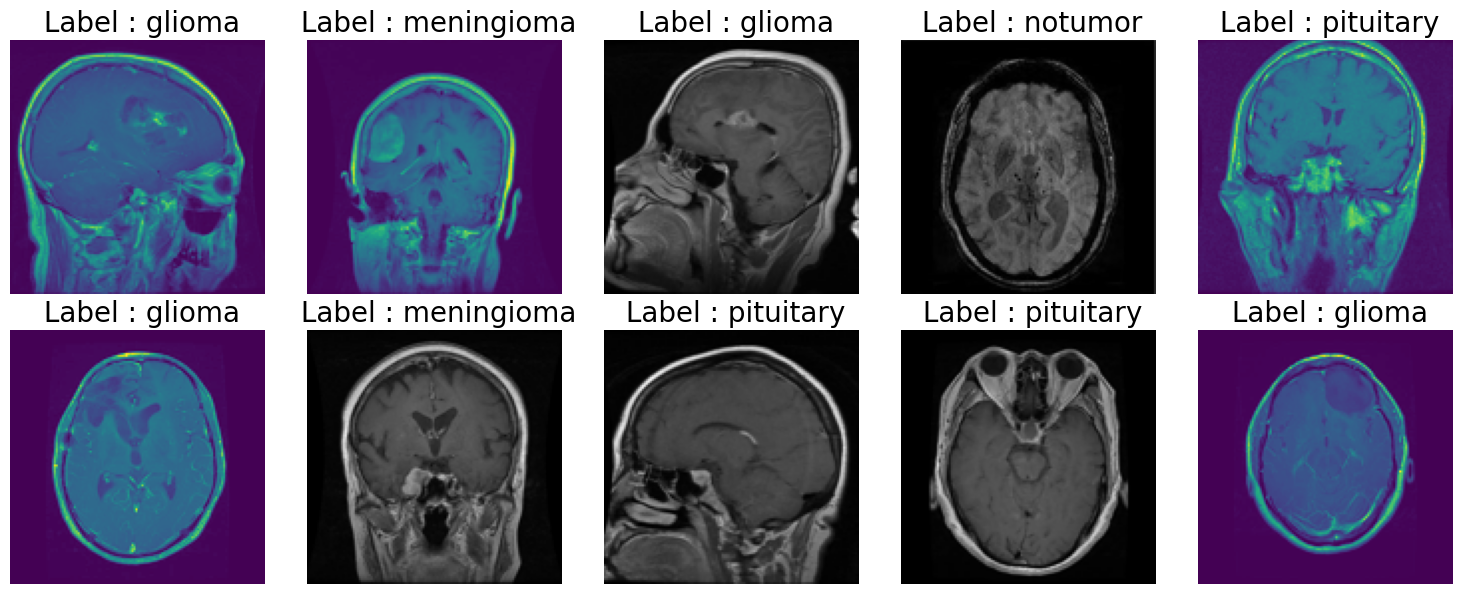

In [13]:
random_indices = random.sample(range(len(train_paths)), 10)

fig, axes =plt.subplots(2,5 ,figsize=(15,6))
axes =axes.ravel()
for i,idx in enumerate(random_indices):
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((128,128))
  axes[i].imshow(img)
  axes[i].axis ('off')
  axes[i].set_title(f" Label : {train_labels[idx]}" , fontsize =20)
plt.tight_layout()
plt.show()





In [14]:
def augment(image) :
  pass
def open_images(paths):
  pass
def datagen(apths ,labels,batch_size=12,epoch=1):
  pass

In [ ]:
IMAGE_SIZE =128
base_model =VGG16(input_shape = (IMAGE_SIZE,IMAGE_SIZE,3),include_top=False,weights='imagenet')

for layer in base_model.layers:
  layer.trainable = False

base_model.layers[-2].trainable =True
base_model.layers[-3].trainable =True
base_model.layers[-4].trainable =True


model =Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(len(os.listdir(train_dir)),activation="softmax"))
model.compile(optimizer = Adam(learning_rate=0.0001),loss = 'sparse_categorical_crossentropy',metrics=['sparse_categorical_accuracy'])



batch_size =20
steps=int(len((train_paths) / batch_aize))
epochs = 5


history = model.fit(
    datagen(train_paths.train_labels,batch_size=batch_size,epoch=epochs),
    steps_per_epoch=steps,
    epochs=epochs,
    validation_data=datagen(test_paths,test_labels,batch_size=batch_size
)
